# Example 7: Bayesian optimization for model calibration

This notebook demonstrates how to perform Bayesian optimization (BO) for model calibration and parameter estimation using the [virus-mac-new](https://github.com/heberlr/UQ_PhysiCell//tree/main/examples/virus-mac-new) PhysiCell model. Bayesian optimization is a powerful technique for optimizing expensive black-box functions, making it ideal for calibrating computational models against experimental or observational data.

The calibration process uses a multi-objective approach to minimize the discrepancy between model predictions and observed data across multiple quantities of interest (QoIs). The method employs:

1. **Gaussian Process surrogate models**: To efficiently approximate the parameter-to-QoI mapping
2. **Acquisition functions**: To intelligently select new parameter combinations for evaluation
3. **Multi-objective optimization**: To simultaneously optimize multiple fitness criteria
4. **Pareto front analysis**: To identify trade-offs between competing objectives

The observational data represents the "ground truth" generated from a single simulation with known parameter values:
- **mac_phag_rate_infected**: 1.0 (rate at which macrophages phagocytose infected epithelial cells)
- **epi2infected_hfm**: 0.4 (half-maximum rate for epithelial cell infection transition)

The *in silico* observational data ([ex7_ObsData.csv](ex7_ObsData.csv)) was generated using [ex7_GenerateData.ipynb](ex7_GenerateData.ipynb). The goal is to recover these parameter values through the optimization process.

## Import modules and set up parameters

In [ ]:
from uq_physicell.bo import CalibrationContext, run_bayesian_optimization, analyze_pareto_results, plot_parameter_space, plot_qoi_param, plot_parameter_vs_fitness, get_observed_qoi
from uq_physicell.utils.distances import SumSquaredDifferences
from uq_physicell.database.bo_db import load_structure
import matplotlib.pyplot as plt

# Real values for obs. data
dic_real_value = {'mac_phag_rate_infected': 1.0, 'epi2infected_hfm': 0.4}

# File name
db_path = "ex7_Calib_BO.db"
obs_data_path = "ex7_ObsData.csv"

# Model configuration
model_config = {
    "ini_path": "uq_pc_struc.ini", 
    "struc_name": "Model_struc_Calib", 
}

# Quantities of Interest (QoI) functions
qoi_functions = {
    "epi_": "lambda df: len(df[df['cell_type'] == 'epithelial'])", 
    "epi_infected": "lambda df: len(df[df['cell_type'] == 'epithelial_infected'])"
}

# Mapping of QoI names to observed data columns
obs_data_columns = {
    'time': "Time", 
    "epi_": "Healthy Epithelial Cells", 
    "epi_infected": "Infected Epithelial Cells"
}
# Parameter search space with bounds
search_space = {
    "mac_phag_rate_infected": {"type": "real", "lower_bound": 0.7, "upper_bound": 1.5},
    "epi2infected_hfm": {"type": "real", "lower_bound": 0.1, "upper_bound": 0.5},
}
# Bayesian Optimization options (Optimized for better performance)
bo_options = {
    "num_initial_samples": 10,  # Increased for better initial coverage
    "num_iterations": 30,  # More iterations for better exploration
    "max_workers": 10,  # Adjusted for optimal performance
}

## Create the context and run the Bayesian Optimization calibration

In [2]:
# Create the calibration context
calib_context = CalibrationContext(
    db_path=db_path,
    obsData=obs_data_path,
    obsData_columns=obs_data_columns,
    model_config=model_config,
    qoi_functions=qoi_functions,
    search_space=search_space,
    bo_options=bo_options,
)
# Run the Bayesian Optimization calibration
run_bayesian_optimization(calib_context)

2026-02-09 16:45:45,408 - INFO - 📊 Estimating weights from observational data ranges:
  📈 epi_ - weight: 4.44e-04 (range=2.50e+02)
  📈 epi_infected - weight: 1.19e-04 (range=9.36e+02)

2026-02-09 16:45:45,409 - INFO - 🔧 CalibrationContext initialized with 10 max workers, 5 inner workers, and 2 outer workers.
2026-02-09 16:45:45,409 - INFO - 🆕 Starting fresh optimization with database: ex7_Calib_BO.db
2026-02-09 16:45:45,413 - INFO - 🎲 Generating 10 initial samples...
2026-02-09 16:52:37,572 - INFO - 🔬 Detected multiple QoIs - using multi-objective Bayesian optimization loop.
2026-02-09 16:52:37,574 - INFO - ============================================================
2026-02-09 16:52:37,574 - INFO - 🔄 Multi-Objective BO Iteration 1/30
2026-02-09 16:52:37,574 - INFO - ============================================================
2026-02-09 16:52:37,574 - INFO - 🔧 Fitting Gaussian Process models...
2026-02-09 16:52:37,907 - INFO - 🎯 Optimizing acquisition function...
2026-02-09 16:52:38,1

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-02-09 16:57:56,687 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-02-09 16:57:56,687 - INFO - 	 Candidate 1: {'mac_phag_rate_infected': 1.5, 'epi2infected_hfm': 0.5}
2026-02-09 16:58:31,250 - INFO - 	 Results for Sample ID 15: Objectives = {'epi_': np.float64(1.2966052562524497e-14), 'epi_infected': np.float64(2.1124446571853598e-21)}, Noise Std = {'epi_': np.float64(2.593208688880251e-14), 'epi_infected': np.float64(4.224889314359042e-21)}
2026-02-09 16:58:31,255 - INFO - 📊 Iteration 6 Sample(s) [15] : Hypervolume = 2.5588881436469547e-07
2026-02-09 16:58:31,255 - INFO - ✅ Completed iteration 6/30 - Total samples: 16
2026-02-09 16:58:31,255 - INFO - 🎯 Best fitness values:
2026-02-09 16:58:31,256 - INFO - 	 Best parameters for best fitness of epi_ (sample 6): {'mac_phag_rate_infected': 1.3963041305541992, 'epi2infected_hfm': 0.3750448226928711}
2026-02-09 16:58:31,256 - INFO - 	 Fitness: {'epi_': 0.39369828365734294, 'epi_infected': 0.21901773715669806}.
2026-02-09 16:58:31,256 

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-02-09 16:58:31,670 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-02-09 16:58:31,671 - INFO - 	 Candidate 1: {'mac_phag_rate_infected': 0.7, 'epi2infected_hfm': 0.5}
2026-02-09 16:59:04,921 - INFO - 	 Results for Sample ID 16: Objectives = {'epi_': np.float64(5.571193859988273e-20), 'epi_infected': np.float64(2.723022760712618e-32)}, Noise Std = {'epi_': np.float64(1.062545821148948e-19), 'epi_infected': np.float64(5.445710228339915e-32)}
2026-02-09 16:59:04,926 - INFO - 📊 Iteration 7 Sample(s) [16] : Hypervolume = 2.538938630795479e-07
2026-02-09 16:59:04,926 - INFO - ✅ Completed iteration 7/30 - Total samples: 17
2026-02-09 16:59:04,927 - INFO - 🎯 Best fitness values:
2026-02-09 16:59:04,927 - INFO - 	 Best parameters for best fitness of epi_ (sample 6): {'mac_phag_rate_infected': 1.3963041305541992, 'epi2infected_hfm': 0.3750448226928711}
2026-02-09 16:59:04,927 - INFO - 	 Fitness: {'epi_': 0.39369828365734294, 'epi_infected': 0.21901773715669806}.
2026-02-09 16:59:04,927 - I

...

2026-02-09 17:18:59,969 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-02-09 17:18:59,969 - INFO - 	 Candidate 1: {'mac_phag_rate_infected': 0.7, 'epi2infected_hfm': 0.5}
2026-02-09 17:19:33,207 - INFO - 	 Results for Sample ID 37: Objectives = {'epi_': np.float64(3.2346094114447123e-16), 'epi_infected': np.float64(8.922578760079406e-27)}, Noise Std = {'epi_': np.float64(6.46912766026296e-16), 'epi_infected': np.float64(1.7845157502758396e-26)}
2026-02-09 17:19:33,211 - INFO - 📊 Iteration 28 Sample(s) [37] : Hypervolume = 1.4119051724258744e-07
2026-02-09 17:19:33,211 - INFO - 🔍 Analyzing convergence...
2026-02-09 17:19:33,212 - WARNING - ⚠️  High noise detected (max 151.4%) - using relaxed convergence criteria
2026-02-09 17:19:33,212 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-02-09 17:19:33,213 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-02-09 17:19:33,213 - INFO - 	🎯 Confidence: 33.36%
2026-02-09 17:19:33,213 - INFO

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-02-09 17:19:33,775 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-02-09 17:19:33,775 - INFO - 	 Candidate 1: {'mac_phag_rate_infected': 1.5, 'epi2infected_hfm': 0.2881987912846493}
2026-02-09 17:20:36,754 - INFO - 	 Results for Sample ID 38: Objectives = {'epi_': np.float64(2.562144665116165e-16), 'epi_infected': np.float64(1.3364923093855954e-37)}, Noise Std = {'epi_': np.float64(3.0289043399231095e-16), 'epi_infected': np.float64(1.6368621015743088e-37)}
2026-02-09 17:20:36,759 - INFO - 📊 Iteration 29 Sample(s) [38] : Hypervolume = 1.3653535478125492e-07
2026-02-09 17:20:36,759 - INFO - 🔍 Analyzing convergence...
2026-02-09 17:20:36,759 - WARNING - ⚠️  High noise detected (max 151.4%) - using relaxed convergence criteria
2026-02-09 17:20:36,760 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-02-09 17:20:36,760 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-02-09 17:20:36,760 - INFO - 	🎯 Confidence: 33.34%
2026-02-09 17

/Users/heberlr/.pyenv/versions/pcvenv/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


2026-02-09 17:20:37,229 - INFO - 📊 Evaluating 1 new candidate(s)...
2026-02-09 17:20:37,230 - INFO - 	 Candidate 1: {'mac_phag_rate_infected': 0.7, 'epi2infected_hfm': 0.1}
2026-02-09 17:21:55,222 - INFO - 	 Results for Sample ID 39: Objectives = {'epi_': np.float64(3.522708646794959e-26), 'epi_infected': np.float64(1.670801906886273e-103)}, Noise Std = {'epi_': np.float64(0.0), 'epi_infected': np.float64(3.3416034003830947e-103)}
2026-02-09 17:21:55,227 - INFO - 📊 Iteration 30 Sample(s) [39] : Hypervolume = 1.3214013004010972e-07
2026-02-09 17:21:55,227 - INFO - 🔍 Analyzing convergence...
2026-02-09 17:21:55,227 - WARNING - ⚠️  High noise detected (max 151.4%) - using relaxed convergence criteria
2026-02-09 17:21:55,228 - INFO - 	📋 Convergence Status: stuck_suboptimal
2026-02-09 17:21:55,228 - INFO - 	💡 Reason: Stuck in suboptimal region: poor exploration or quality despite stagnation
2026-02-09 17:21:55,228 - INFO - 	🎯 Confidence: 33.34%
2026-02-09 17:21:55,229 - INFO - 	📊 Noise leve

In [3]:
# Load the database and perform analysis
df_metadata, df_param_space, df_qois, df_gp_models, df_samples, df_output = load_structure(db_path)
   

## Obtain the Pareto front point(s)

🔍 COMPREHENSIVE PARETO ANALYSIS

📊 Extracting all Pareto points ...
🎯 Current Pareto front size: 1

🎯 CURRENT PARETO FRONT:
   Number of Pareto optimal points: 1
   Sample IDs: [6]

   📋 Pareto Front Details:
   Point 1 (Sample 6):
      Fitness: {'epi_': np.float64(0.39369828365734294), 'epi_infected': np.float64(0.21901773715669806)}
      Parameters: {'mac_phag_rate_infected': 1.3963041305541992, 'epi2infected_hfm': 0.3750448226928711}


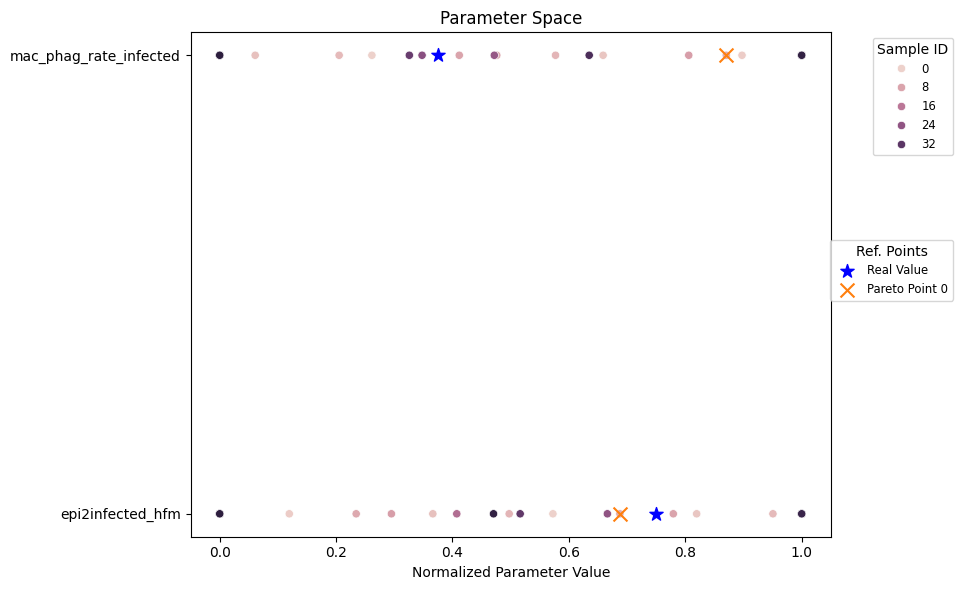

In [4]:
# Comprehensive Pareto analysis
pareto_data = analyze_pareto_results(df_qois, df_samples, df_output)
# Plot with pareto front points
pareto_points = {f"Pareto Point {i}": param for i, param in enumerate(pareto_data['pareto_front']['parameters'])}
plot_parameter_space(df_samples, df_param_space, params=pareto_points, real_value=dic_real_value)
df_obs_qoi = get_observed_qoi(df_metadata['ObsData_Path'].values[0], df_qois)


## Vizualize QoIs from Pareto front point(s)

Plotting epi_
Sample ID: [6]
Objective Function Values:
{'epi_': np.float64(0.39369828365734294), 'epi_infected': np.float64(0.21901773715669806)}
Noise of Objective Function:
{'epi_': np.float64(0.30208151539495787), 'epi_infected': np.float64(0.2682537859516873)}
Plotting epi_infected
Sample ID: [6]
Objective Function Values:
{'epi_': np.float64(0.39369828365734294), 'epi_infected': np.float64(0.21901773715669806)}
Noise of Objective Function:
{'epi_': np.float64(0.30208151539495787), 'epi_infected': np.float64(0.2682537859516873)}


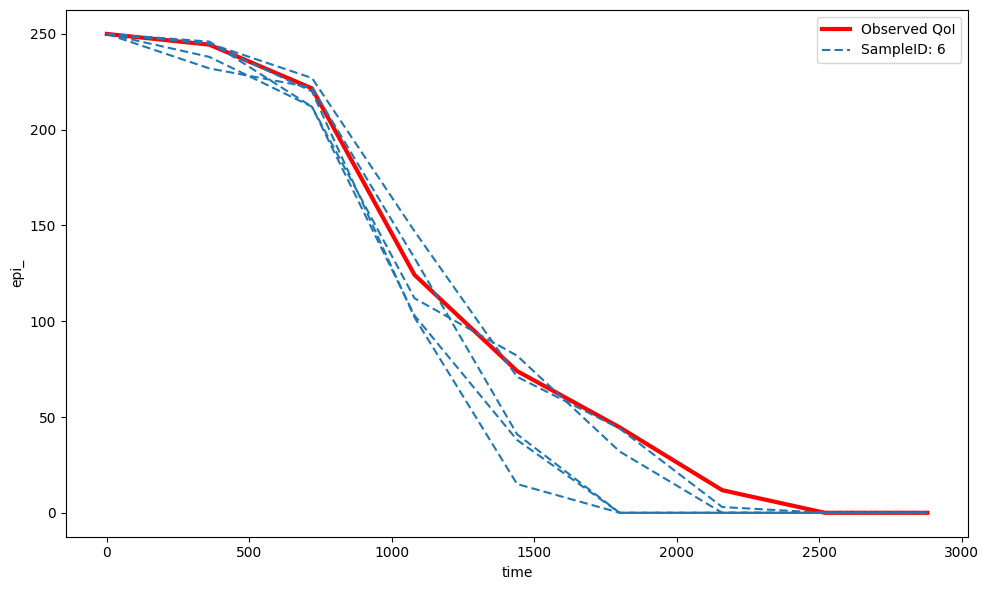

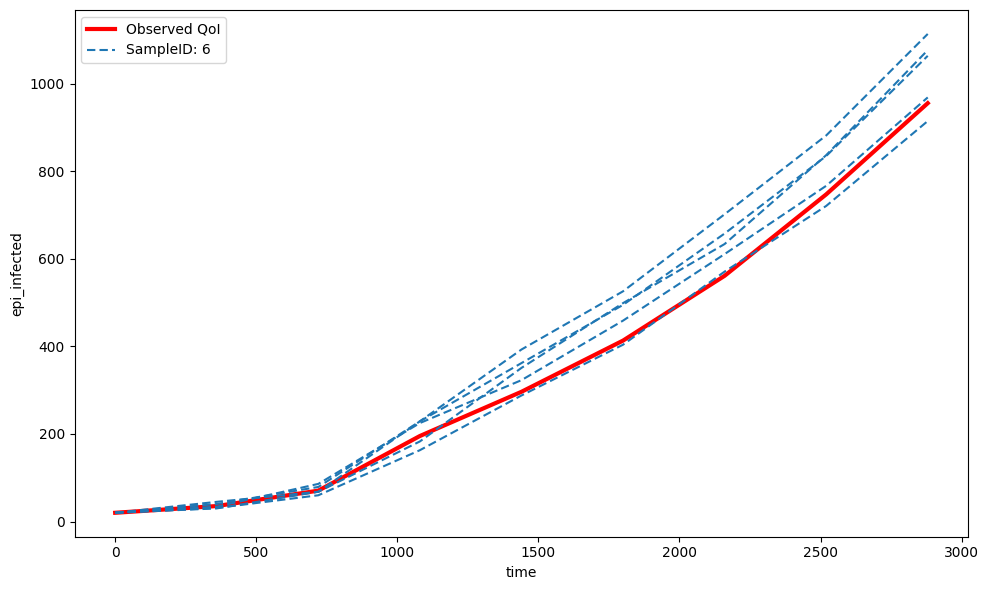

In [5]:
# Plot QoIs of best parameters
for qoi in df_qois['QoI_Name']:
    print(f"Plotting {qoi}")
    plot_qoi_param(df_obs_qoi, df_output, pareto_data['pareto_front']['sample_ids'], x_var='time', y_var=qoi)

## Vizualize the QoIs fitness vs Parameters values

Plotting mac_phag_rate_infected vs epi_
Plotting mac_phag_rate_infected vs epi_infected
Plotting epi2infected_hfm vs epi_
Plotting epi2infected_hfm vs epi_infected


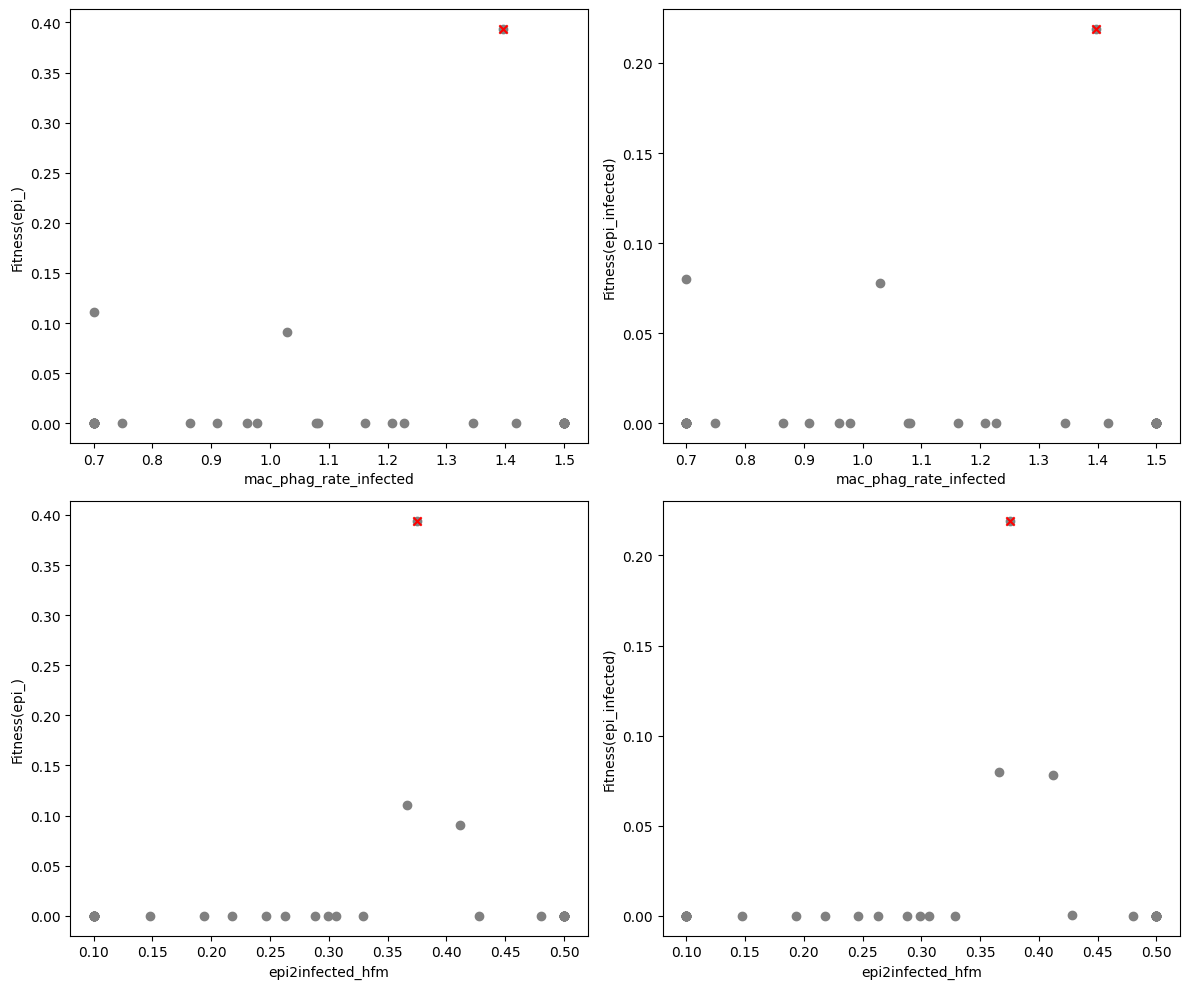

In [6]:
# Plot each parameter vs each QoI
fig, axes = plt.subplots(len(df_param_space), len(df_qois['QoI_Name']), figsize=(12, 10))
fig.subplots_adjust(hspace=0.5, wspace=0.5)  # Increased spacing
for i, param in enumerate(df_param_space['ParamName']):
    for j, qoi in enumerate(df_qois['QoI_Name']):
        print(f"Plotting {param} vs {qoi}")
        plot_parameter_vs_fitness(df_samples, df_output, param, qoi, samples_id=pareto_data['pareto_front']['sample_ids'], axis= axes[i, j])

# Ensure proper layout and save the figure
plt.tight_layout()  # This will automatically adjust spacing to prevent overlaps